# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 04: Transformações dos Dados (Pré-processamento)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA _PRESENCIALMENTE_ COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br), EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                              | Local           |
|-------------------------------|---------------|-----------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Segunda-feira | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quarta-feira  | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sexta-feira   | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_04_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='cyan'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q</font>

Base de dados vinda de um comércio online, cujo objetivo é predizer a vontade de um visitante de comprar e as chances de o mesmo abandonar o site. Ele possui 10 atributos numéricos e 8 categóricos, incluindo dados de sessão e outras métricas.

## <font color='green'>Preparação</font>

In [1]:
!pip install pandas scikit-learn ucimlrepo

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=468)

_X_uci = ds.data.features
_y_uci = ds.data.targets

df = pd.concat([_X_uci, _y_uci], axis='columns')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='cyan'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Não devemos realizar essas transformações antes de dividir o dataset para evitar o vazamento de dados, que é quando nossas métricas são infectadas pelos dados futuro(a parte de teste) em quanto se está transformando a parte de treino

### <font color='cyan'>Q2: Utilizando a função `train_test_split` biblioteca `scikit-learn`, divida as variáveis independentes (`X`) e a variável alvo (`y`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(_X_uci, _y_uci, test_size=0.2, random_state=42)

## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='cyan'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_train`).</font>

In [4]:
cat_cols = X_train.select_dtypes(exclude="number").columns
cat_cols

Index(['Month', 'VisitorType', 'Weekend'], dtype='object')

### <font color='cyan'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras originais.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [5]:
X_train["VisitorType"].sample(10,random_state=42)

,VisitorType
5258,Returning_Visitor
8368,Other
5564,Returning_Visitor
10481,Returning_Visitor
4570,Returning_Visitor
4815,Returning_Visitor
8558,Returning_Visitor
5247,Returning_Visitor
7681,Returning_Visitor
10353,New_Visitor


### <font color='cyan'>Q5: Aplique a técnica de `One-Hot Encoding` na variável escolhida utilizando a biblioteca scikit-learn.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='cyan'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

hot = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
visitor_train_hot = hot.fit_transform(X_train[["VisitorType"]])
visitor_test_hot = hot.transform(X_test[['VisitorType']])
visitor_test_hot

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]])

### <font color='cyan'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='cyan'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [7]:
hot_visitor_train = pd.DataFrame(data = visitor_train_hot, columns=hot.get_feature_names_out(), index=X_train.index)
hot_visitor_train.sample(10,random_state=42)

,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
5258,0.0,0.0,1.0
8368,0.0,1.0,0.0
5564,0.0,0.0,1.0
10481,0.0,0.0,1.0
4570,0.0,0.0,1.0
4815,0.0,0.0,1.0
8558,0.0,0.0,1.0
5247,0.0,0.0,1.0
7681,0.0,0.0,1.0
10353,1.0,0.0,0.0


## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='cyan'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

Pois eles usam a distância entre os dados como parâmetro, assim, se eles não estiverem escalonados, a diferença entre escalas levará a um modelo distorcido.

### <font color='cyan'>Q8: Selecione uma coluna numérica contínua de `X_train`. Escreva o nome da característica selecionada abaixo.</font>

In [8]:
num_cols = df.select_dtypes(include="number").columns
num_cols[df[num_cols].nunique()>50]

Index(['Administrative_Duration', 'Informational_Duration', 'ProductRelated',
       'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues'],
      dtype='object')

ExitRates



### <font color='cyan'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [9]:
print(f"A mediana é: {df["ExitRates"].median()}")
df["ExitRates"].describe()

A mediana é: 0.0251564025


,ExitRates
count,12330.000000
mean,0.043073
std,0.048597
min,0.000000
25%,0.014286
50%,0.025156
75%,0.050000
max,0.200000


### <font color='cyan'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

<Axes: xlabel='ExitRates', ylabel='Count'>

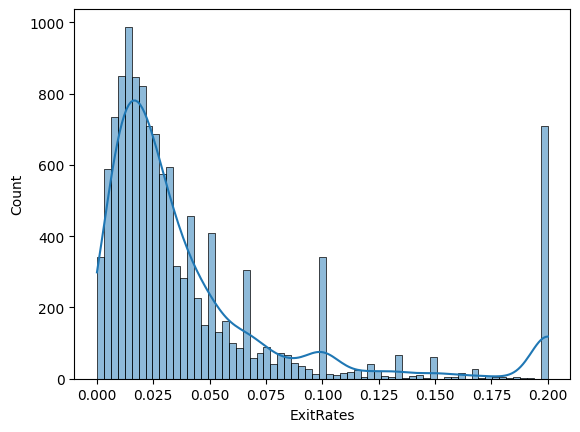

In [10]:
import seaborn as sns

sns.histplot(data = df, x = "ExitRates", kde = True)

### <font color='cyan'>Q11: Aplique o Escalonamento nesta variável. Você pode escolher entre a Padronização (`StandardScaler`) ou a Normalização (`MinMaxScaler`), ambas da biblioteca scikit-learn.</font>

- #### <font color='cyan'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_train` e `X_test`) pelos valores escalonados.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>

In [11]:
scaler = StandardScaler()
X_train['ExitRates'] = scaler.fit_transform(X_train[['ExitRates']])
X_test['ExitRates'] =  scaler.transform(X_test[['ExitRates']])

### <font color='cyan'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [12]:
print(f"Para o treino:\n{X_train['ExitRates'].describe()}\n e sua mediana: {X_train['ExitRates'].median()}\n")
print(f"Para o teste:\n{X_test['ExitRates'].describe()}\n e sua mediana: {X_test['ExitRates'].median()}")

Para o treino:
count    9.864000e+03
mean    -1.379450e-16
std      1.000051e+00
min     -8.908202e-01
25%     -5.921813e-01
50%     -3.682021e-01
75%      1.544159e-01
max      3.290124e+00
Name: ExitRates, dtype: float64
 e sua mediana: -0.3682021142048096

Para o teste:
count    2466.000000
mean        0.048023
std         1.076309
min        -0.890820
25%        -0.599294
50%        -0.342437
75%         0.154416
max         3.290124
Name: ExitRates, dtype: float64
 e sua mediana: -0.3424371910122728


### <font color='cyan'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

<Axes: xlabel='ExitRates', ylabel='Count'>

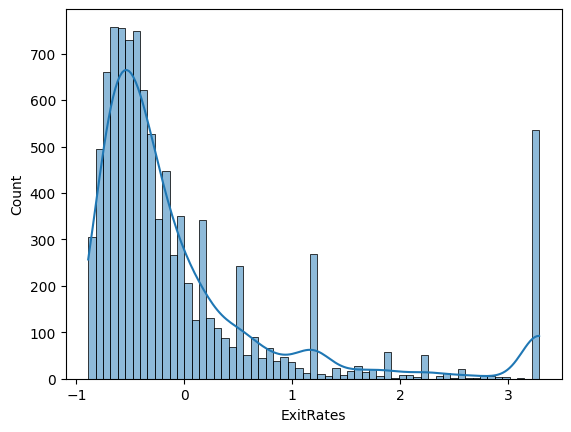

In [13]:
sns.histplot(data = X_train, x = "ExitRates", kde = True)

### <font color='cyan'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='cyan'>O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='cyan'>O que aconteceu com a escala do eixo X e com o formato da curva no gráfico?</font>

*   A média antes do escalonamento era 0.043073 e depois ficou -2.377120e-17.
*   O desvio padrão antes era 0.048597 e depois ficou de 1.000051e+00
*   A escala do eixo X mudou, como esperado para um escalonamento, mas o formato se manteve, como esperado também.



## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='cyan'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='cyan'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [14]:
# No data frame todo
df["Total Abandon"] = df["BounceRates"]+df["ExitRates"]
# Na parte de teste
X_test["Total Abandon"] = X_test["BounceRates"]+X_test["ExitRates"]
# Na parte de treinamento
X_train["Total Abandon"] = X_train["BounceRates"]+X_train["ExitRates"]

### <font color='cyan'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [15]:
X_train['Total Abandon'].sample(10, random_state=42)

,Total Abandon
5258,1.249652
8368,-0.767851
5564,-0.243950
10481,-0.522562
4570,-0.658545
4815,0.270553
8558,0.479343
5247,-0.807201
7681,-0.572272
10353,0.821558


### <font color='cyan'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_train`).</font>
- #### <font color='cyan'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='cyan'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='cyan'>Importante: Utilize o `LabelEncoder` da biblioteca `scikit-learn` para transformar a variável alvo (`y_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [16]:
label = LabelEncoder()
label_y_train = pd.Series(label.fit_transform(y_train), index= X_train.index)
label_y_test = label.transform(y_test)
corr = label_y_train.corr(X_train["Total Abandon"])
print(f"A correlação de Pearson é de:{corr}")

A correlação de Pearson é de:-0.20338212145657036


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


A correlação foi negativa e fraca, o que indica que o novo atributo, por mais que tenha uma certa correlação, é muito fraca para ajudar no modelo.

## <font color='green'>**3.5 Extração / Seleção de Atributos**</font>

### <font color='cyan'>Q18: Qual a principal diferença conceitual entre Extração de Atributos (ex: `Principal Component Analysis`) e Seleção de Atributos (ex: `Variance Threshold`)? Explique.</font>

A Extração de Atributos tenta criar novos atributos a partir de combinções matemáticas de atributos já existentes, o que é ótimo para diminuir a dimensionalidade do problema. A Seleção de Atributos faz uma seleção dos atributos que possuem uma menor variabilidade e os excluem, na interpretação de que não serão tão interessantes para o modelo, dado que não conseguiram ensinar nada.

### <font color='cyan'>Q19: Aplique a técnica de Análise de Componentes Principais (PCA) em todas as variáveis numéricas escalonadas.</font>

- #### <font color='cyan'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis) e ajuste-o aos dados de treinamento.</font>
- #### <font color='cyan'>b) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='cyan'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='cyan'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='cyan'>c) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

In [17]:
num_cols_sem_exit = num_cols.drop("ExitRates")
X_train[num_cols_sem_exit] = scaler.fit_transform(X_train[num_cols_sem_exit])
X_test[num_cols_sem_exit] =  scaler.transform(X_test[num_cols_sem_exit])

In [18]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_train[num_cols])

PCA()

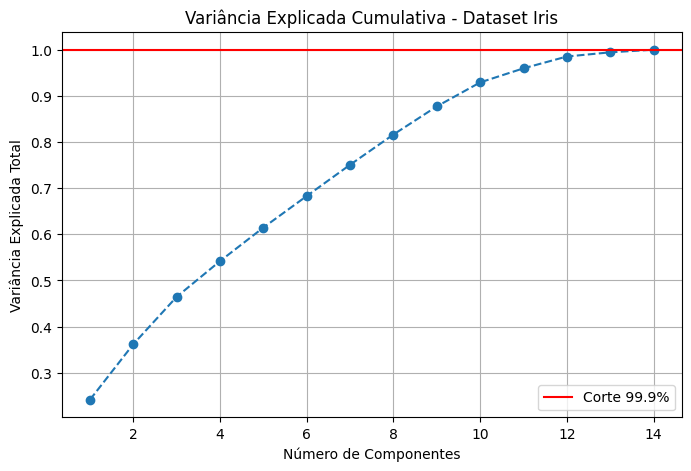

In [19]:
import matplotlib.pyplot as plt
import numpy as np

variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.999, color='r', linestyle='-', label='Corte 99.9%')
plt.title('Variância Explicada Cumulativa - Dataset Iris')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Total')
plt.grid(True)
plt.legend()
plt.show()

Visualmente, o número de componentes mínimos para atingir o limiar de corte vai ser 14 componentes,esse valor é para garantir que a redução de dimensionalidade não resulte em perda de sinal relevante, eliminando apenas a redundância matemática absoluta.

### <font color='cyan'>Q20: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='cyan'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='cyan'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='cyan'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='cyan'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [20]:
pca_final = PCA(n_components=0.999)

X_train_pca = pca_final.fit_transform(X_train[num_cols])
X_test_pca = pca_final.transform(X_test[num_cols])

In [21]:
print(f"Shape original: {X_train[num_cols].shape}")
print(f"Shape após PCA (99.9%): {X_train_pca.shape}")
print(f"Número de componentes selecionados: {pca_final.n_components_}")

Shape original: (9864, 14)
Shape após PCA (99.9%): (9864, 14)
Número de componentes selecionados: 14


In [22]:
pesos_pc1 = pca_final.components_[0]

df_pesos = pd.DataFrame({
    'Atributo': num_cols,
    'Peso_PC1': pesos_pc1,
    'Peso_Absoluto': np.abs(pesos_pc1)
})

top_5_influentes = df_pesos.sort_values(by='Peso_Absoluto', ascending=False).head(5)

print("Os 5 principais atributos que mais influenciam a PC1 são:")
top_5_influentes[['Atributo', 'Peso_PC1']]

Os 5 principais atributos que mais influenciam a PC1 são:


,Atributo,Peso_PC1
5,ProductRelated_Duration,0.411192
4,ProductRelated,0.411079
0,Administrative,0.382999
2,Informational,0.344909
1,Administrative_Duration,0.328254
